In [51]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
from scipy import stats



In [39]:
import pandas as pd

df = pd.read_csv("provider_level_cohorted.csv")
df

,billing_provider_npi,num_hcpcs_codes,months_active,beneficiaries_total,beneficiaries_mean,beneficiaries_median,claims_total,claims_mean,claims_median,paid_total,paid_mean,paid_median,state,entity_type_code,primary_taxonomy,cohort,cohort_label
0,1003000134,2,73,2368.0,31.573333,32.0,2858.0,38.106667,39.0,59809.17,797.455600,724.160,IL,1,207ZP0102X,35,IL_individual
1,1003000217,7,76,10792.0,22.024490,19.5,11730.0,23.938776,22.0,524948.58,1071.323633,929.775,WV,2,152W00000X,114,WV_organization
2,1003000274,12,82,9987.0,27.896648,19.0,11064.0,30.905028,21.0,625319.26,1746.701844,1503.600,LA,2,2084N0400X,44,LA_organization
3,1003000514,2,19,546.0,14.368421,13.5,1548.0,40.736842,41.0,38173.90,1004.576316,997.850,WI,2,314000000X,112,WI_organization
4,1003000563,6,4,160.0,13.333333,13.0,182.0,15.166667,14.0,0.00,0.000000,0.000,CA,2,261QP2300X,12,CA_organization
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605827,1619596376,2,27,3836.0,72.377358,71.0,13740.0,259.245283,262.0,2832087.05,53435.604717,50455.440,NJ,1,101YM0800X,73,NJ_individual
605828,1619596566,2,1,56.0,18.666667,18.0,66.0,22.000000,22.0,795.00,265.000000,0.000,TX,2,261QU0200X,100,TX_organization
605829,1619596616,2,2,40.0,13.333333,13.0,40.0,13.333333,13.0,1371.09,457.030000,453.320,NY,1,207P00000X,79,NY_individual
605830,1619596806,6,32,1529.0,22.159420,19.0,1703.0,24.681159,20.0,96965.46,1405.296522,1398.170,NV,2,208800000X,78,NV_organization


In [46]:
df.columns

Index(['billing_provider_npi', 'num_hcpcs_codes', 'months_active',
       'beneficiaries_total', 'beneficiaries_mean', 'beneficiaries_median',
       'claims_total', 'claims_mean', 'claims_median', 'paid_total',
       'paid_mean', 'paid_median', 'state', 'entity_type_code',
       'primary_taxonomy', 'cohort', 'cohort_label'],
      dtype='str')

In [40]:
pd.set_option("display.max_columns", None)
print(df.iloc[2343])

billing_provider_npi       1124169446
num_hcpcs_codes                     2
months_active                      48
beneficiaries_total             755.0
beneficiaries_mean          15.729167
beneficiaries_median             15.0
claims_total                   1162.0
claims_mean                 24.208333
claims_median                    23.0
paid_total                   28487.84
paid_mean                  593.496667
paid_median                   600.485
state                              MN
entity_type_code                    1
primary_taxonomy           111N00000X
cohort                             55
cohort_label            MN_individual
Name: 2343, dtype: object


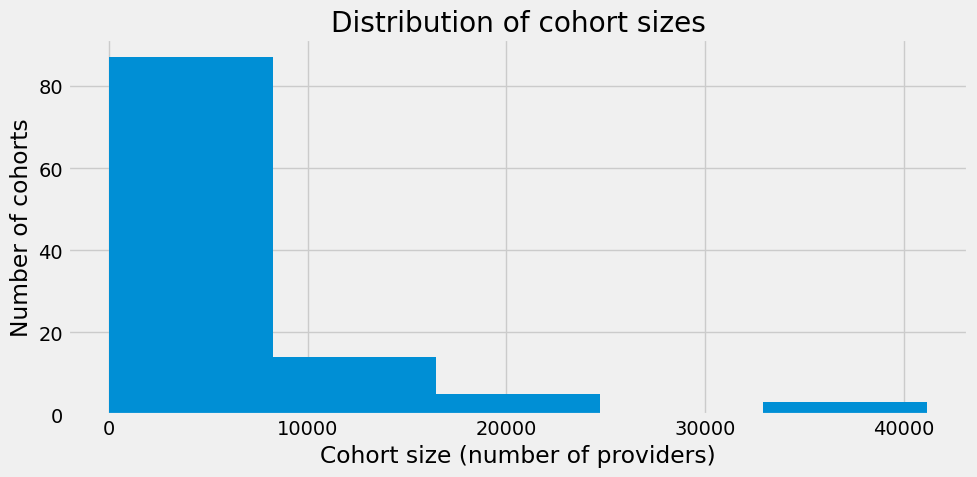

In [41]:
# Distribution of cohort sizes (how many providers per cohort)
cohort_sizes = df["cohort"].value_counts()

plt.figure(figsize=(10, 5))
plt.hist(cohort_sizes.values, bins=5)
plt.xlabel("Cohort size (number of providers)")
plt.ylabel("Number of cohorts")
plt.title("Distribution of cohort sizes")
plt.tight_layout()
plt.show()

In [42]:
cohort_sizes.describe()

count      109.000000
mean      5558.091743
std       7233.293584
min          1.000000
25%       1420.000000
50%       3246.000000
75%       6658.000000
max      41160.000000
Name: count, dtype: float64

In [43]:
df["cohort"].nunique()

109

In [45]:
cohort_sizes = df["cohort"].value_counts()
small_cohort_ids = cohort_sizes[cohort_sizes < 1000].index

# One row per cohort: cohort, cohort_label, size
small = (
    df[df["cohort"].isin(small_cohort_ids)][["cohort", "cohort_label"]]
    .drop_duplicates("cohort")
    .set_index("cohort")
)
small["size"] = cohort_sizes[small.index]
small.sort_values("cohort")

,cohort_label,size
cohort,,
1,AK_individual,272
17,DC_individual,568
18,DC_organization,783
19,DE_individual,385
24,FM_organization,1
27,GU_individual,39
28,GU_organization,69
29,HI_individual,708
33,ID_individual,680


In [47]:
cohort_label = "NM_organization"
n = (df["cohort_label"] == cohort_label).sum()
print(f"{cohort_label}: {n} providers")

NM_organization: 3166 providers


# OLD COHORT ANALSYSIS

,grouping,n_groups,min_size,max_size,mean_size,median_size,n_UNKNOWN_groups,n_singleton_groups
primary_taxonomy,primary_taxonomy,730,1,29316,829.980822,51.0,0,70
primary_taxonomy+state,primary_taxonomy+practice_state,16408,1,5161,36.926255,4.0,0,4237
practice_state,practice_state,83,1,59300,7299.831325,3263.0,0,22
entity_type,entity_type,2,267467,338419,302943.000000,302943.0,0,0
state+entity_type,practice_state+entity_type,139,1,41160,4358.892086,2215.0,0,23
tax+state+entity,primary_taxonomy+practice_state+entity_type,22735,1,4146,26.649923,3.0,0,6921


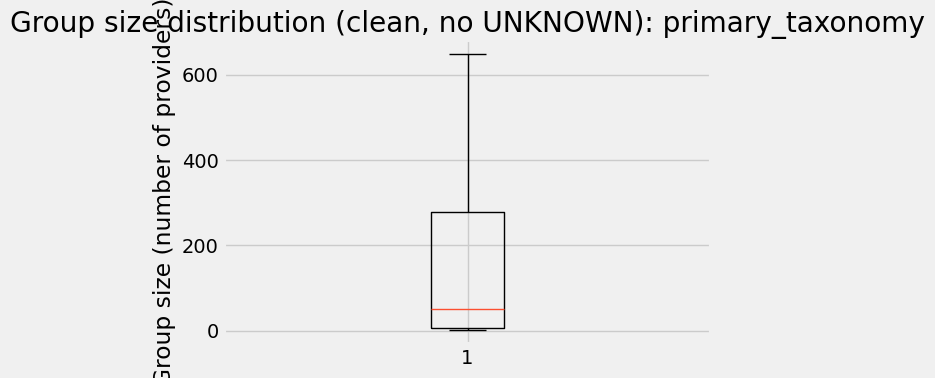

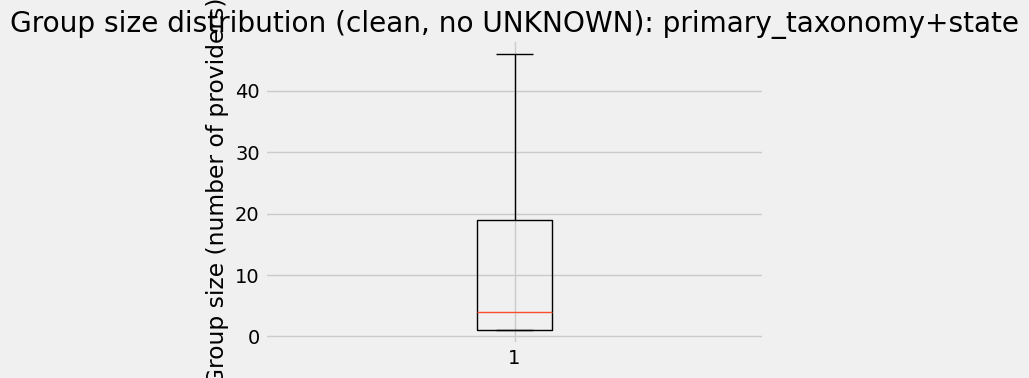

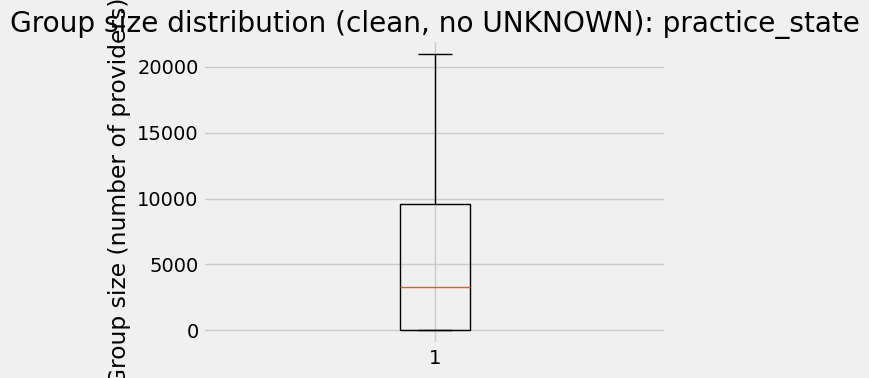

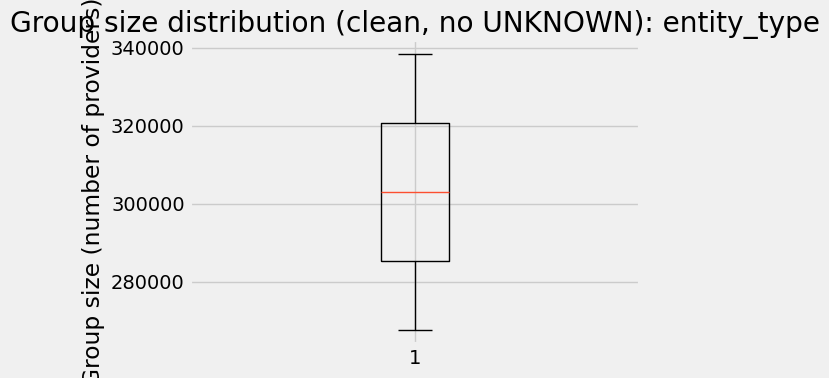

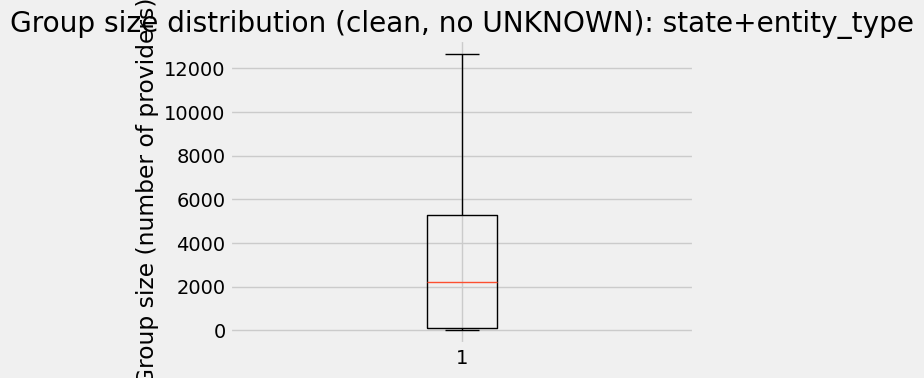

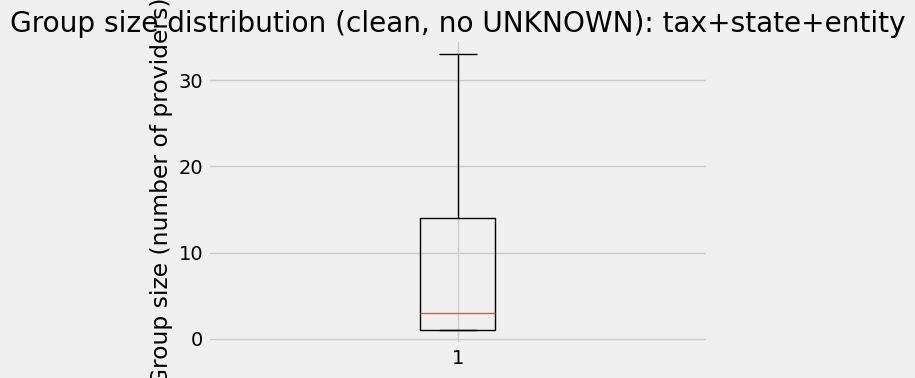

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume:
# df  = provider-level data with column "billing_provider_npi"
# df2 = NPPES cohort-feature data with columns:
#       "npi", "primary_taxonomy", "practice_state", "entity_type"

# Restrict df2 to NPIs that appear as billing_provider_npi in df
common_npis = set(df["billing_provider_npi"].astype(str))
df2_overlap = df2[df2["npi"].astype(str).isin(common_npis)].copy()

# Drop rows in df2_overlap where any of entity_type, practice_state,
# or primary_taxonomy is UNKNOWN or missing
mask_valid = (
    df2_overlap["entity_type"].notna()
    & df2_overlap["practice_state"].notna()
    & df2_overlap["primary_taxonomy"].notna()
    & (df2_overlap["entity_type"] != "UNKNOWN")
    & (df2_overlap["practice_state"] != "UNKNOWN")
    & (df2_overlap["primary_taxonomy"] != "UNKNOWN")
)
df2_overlap_clean = df2_overlap[mask_valid].copy()

def summarize_groups(s, name):
    sizes = s.value_counts()
    summary = {
        "grouping": name,
        "n_groups": sizes.shape[0],
        "min_size": sizes.min(),
        "max_size": sizes.max(),
        "mean_size": sizes.mean(),
        "median_size": sizes.median(),
        "n_UNKNOWN_groups": (sizes.index == "UNKNOWN").sum(),
        "n_singleton_groups": (sizes == 1).sum(),  # number of groups of size 1
    }
    return summary, sizes

summaries = {}
sizes_store = {}

# 1) primary taxonomy only
summaries["primary_taxonomy"], sizes_store["primary_taxonomy"] = summarize_groups(
    df2_overlap_clean["primary_taxonomy"], "primary_taxonomy"
)

# 2) primary taxonomy + practice state
summaries["primary_taxonomy+state"], sizes_store["primary_taxonomy+state"] = summarize_groups(
    df2_overlap_clean["primary_taxonomy"].astype(str)
    + "|" + df2_overlap_clean["practice_state"].astype(str),
    "primary_taxonomy+practice_state",
)

# 3) practice state only
summaries["practice_state"], sizes_store["practice_state"] = summarize_groups(
    df2_overlap_clean["practice_state"], "practice_state"
)

# 4) entity type only
summaries["entity_type"], sizes_store["entity_type"] = summarize_groups(
    df2_overlap_clean["entity_type"], "entity_type"
)

# 5) practice state + entity type
summaries["state+entity_type"], sizes_store["state+entity_type"] = summarize_groups(
    df2_overlap_clean["practice_state"].astype(str)
    + "|" + df2_overlap_clean["entity_type"].astype(str),
    "practice_state+entity_type",
)

# 6) primary taxonomy + practice state + entity type
summaries["tax+state+entity"], sizes_store["tax+state+entity"] = summarize_groups(
    df2_overlap_clean["primary_taxonomy"].astype(str)
    + "|" + df2_overlap_clean["practice_state"].astype(str)
    + "|" + df2_overlap_clean["entity_type"].astype(str),
    "primary_taxonomy+practice_state+entity_type",
)

# Show high-level summaries for overlap-only, cleaned cohorts
display(pd.DataFrame.from_dict(summaries, orient="index"))

# ----- Boxplots of group sizes for each grouping -----
for key, sizes in sizes_store.items():
    data = sizes.values  # sizes of groups for this definition

    plt.figure(figsize=(6, 4))
    plt.boxplot(data, showfliers=False)
    plt.ylabel("Group size (number of providers)")
    plt.title(f"Group size distribution (clean, no UNKNOWN): {key}")
    plt.tight_layout()
    plt.show()

In [ ]:
df3 = pd.read_csv("nppes_cohort_features.csv")

In [8]:
df2_overlap["primary_taxonomy"].nunique()

731